<a href="https://colab.research.google.com/github/ValantinaBharathi/FaceAnimation/blob/main/Another_copy_of_Nfaceclip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!jupyter kernelspec list

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
Available kernels:
  julia      /root/.local/share/jupyter/kernels/julia
  ir         /usr/local/share/jupyter/kernels/ir
  python3    /usr/local/share/jupyter/kernels/python3


In [5]:
pip install numpy torch torchvision tqdm matplotlib pillow pathlib

In [1]:
pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-1koxsytw
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-1koxsytw
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=80197bd3efb6956037e6192d73b29a8473b9b1d54022fa97d2eea1dc6a49b1cb
  Stored in directory: /tmp/pip-ephem-wheel-cache-1bvq_4et/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
pip install opencv-python

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import clip
from tqdm import tqdm
import cv2
import dlib
from itertools import groupby

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive(1).zip to archive(1).zip


In [5]:
# ============================================================================
# 0. FACIAL LANDMARK EXTRACTION
# ============================================================================

class LandmarkExtractor:
    """Extract facial landmarks using dlib"""

    def __init__(self):
        # Download shape predictor from:
        # http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
        predictor_path = "shape_predictor_68_face_landmarks.dat"

        if not os.path.exists(predictor_path):
            print(f"WARNING: {predictor_path} not found!")
            print("Please download from: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2")
            print("Using fallback landmark extraction...")
            self.detector = None
            self.predictor = None
        else:
            self.detector = dlib.get_frontal_face_detector()
            self.predictor = dlib.shape_predictor(predictor_path)

    def extract_landmarks(self, image):
        """
        Extract 68 facial landmarks from image
        Returns: numpy array of shape (68, 2) with normalized coordinates
        """
        if self.detector is None:
            # Fallback: return dummy landmarks
            return np.random.randn(68, 2) * 0.1

        # Convert PIL Image to numpy array
        if isinstance(image, Image.Image):
            image = np.array(image)

        # Convert to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Detect faces
        faces = self.detector(gray, 1)

        if len(faces) == 0:
            # No face detected, return zeros
            return np.zeros((68, 2))

        # Get landmarks for first face
        shape = self.predictor(gray, faces[0])
        landmarks = np.array([[p.x, p.y] for p in shape.parts()])

        # Normalize landmarks to [-1, 1] range
        h, w = image.shape[:2]
        landmarks[:, 0] = (landmarks[:, 0] / w) * 2 - 1
        landmarks[:, 1] = (landmarks[:, 1] / h) * 2 - 1

        return landmarks

    def compute_landmark_deformation(self, landmarks_current, landmarks_neutral):
        """
        Compute deformation from neutral to current landmarks
        Returns: deformation vector (68, 2)
        """
        return landmarks_current - landmarks_neutral

In [6]:
# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

def explore_directory_structure(path, max_depth=3, current_depth=0):
    """Explore and print directory structure"""
    path = Path(path)
    if not path.exists():
        print(f"Path does not exist: {path}")
        return

    indent = "  " * current_depth
    print(f"{indent}{path.name}/")

    if current_depth >= max_depth:
        return

    try:
        items = list(path.iterdir())
        dirs = [x for x in items if x.is_dir()]
        files = [x for x in items if x.is_file()]

        # Show first few directories
        for d in dirs[:5]:
            explore_directory_structure(d, max_depth, current_depth + 1)

        if len(dirs) > 5:
            print(f"{indent}  ... and {len(dirs) - 5} more directories")

        # Show first few files
        if files:
            print(f"{indent}  Files: {len(files)} total")
            for f in files[:3]:
                print(f"{indent}    - {f.name}")
            if len(files) > 3:
                print(f"{indent}    ... and {len(files) - 3} more files")
    except PermissionError:
        print(f"{indent}  [Permission Denied]")

class CKPlusDataset(Dataset):
    """CK+ Dataset for facial expression sequences with landmark extraction"""

    def __init__(self, root_dir, transform=None, sequence_length=8, min_sequence_length=3):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.sequence_length = sequence_length
        self.min_sequence_length = min_sequence_length

        print(f"\nExploring dataset structure at: {self.root_dir}")
        print("=" * 70)

        # Check if path exists
        if not self.root_dir.exists():
            raise FileNotFoundError(f"Dataset path does not exist: {self.root_dir}")

        # Explore structure
        explore_directory_structure(self.root_dir, max_depth=3)

        print("\n" + "=" * 70)
        print("Loading sequences...")
        self.sequences = self._load_sequences()

        # Initialize landmark extractor
        print("\nInitializing landmark extractor...")
        self.landmark_extractor = LandmarkExtractor()

        # Emotion labels for CK+
        self.emotions = {
            0: "neutral face",
            1: "angry expression",
            2: "contempt expression",
            3: "disgust expression",
            4: "fear expression",
            5: "happy smile",
            6: "sad expression",
            7: "surprise expression"
        }

    def _load_sequences(self):
        """Load all image sequences from the dataset"""
        sequences = []

        # Method 1: Try standard CK+ structure (Subject/Sequence/Images)
        print("\nMethod 1: Checking standard CK+ structure (Subject/Sequence/Images)...")
        for subject_dir in sorted(self.root_dir.glob("*")):
            if not subject_dir.is_dir():
                continue

            for sequence_dir in sorted(subject_dir.glob("*")):
                if not sequence_dir.is_dir():
                    continue

                # Get all images in the sequence
                images = sorted(list(sequence_dir.glob("*.png")) +
                              list(sequence_dir.glob("*.jpg")) +
                              list(sequence_dir.glob("*.jpeg")) +
                              list(sequence_dir.glob("*.PNG")) +
                              list(sequence_dir.glob("*.JPG")))

                if len(images) >= self.min_sequence_length:
                    sequences.append(images)
                    print(f"  Found sequence: {subject_dir.name}/{sequence_dir.name} with {len(images)} images")

        if len(sequences) == 0:
            # Method 2: Try flat structure with all images
            print("\nMethod 2: Checking flat structure (all images in root)...")
            images = sorted(list(self.root_dir.glob("*.png")) +
                          list(self.root_dir.glob("*.jpg")) +
                          list(self.root_dir.glob("*.jpeg")) +
                          list(self.root_dir.glob("*.PNG")) +
                          list(self.root_dir.glob("*.JPG")))

            if len(images) > 0:
                print(f"  Found {len(images)} images in root directory")
                # Group images into sequences (assume sequential naming)
                for i in range(0, len(images), self.sequence_length):
                    seq = images[i:i+self.sequence_length]
                    if len(seq) >= self.min_sequence_length:
                        sequences.append(seq)

        if len(sequences) == 0:
            # Method 3: Try one level of subdirectories
            print("\nMethod 3: Checking single-level subdirectories...")
            for sub_dir in sorted(self.root_dir.glob("*")):
                if not sub_dir.is_dir():
                    continue

                images = sorted(list(sub_dir.glob("*.png")) +
                              list(sub_dir.glob("*.jpg")) +
                              list(sub_dir.glob("*.jpeg")) +
                              list(sub_dir.glob("*.PNG")) +
                              list(sub_dir.glob("*.JPG")))

                if len(images) >= self.min_sequence_length:
                    sequences.append(images)
                    print(f"  Found sequence: {sub_dir.name} with {len(images)} images")

        if len(sequences) == 0:
            # Method 4: Recursive search for all images
            print("\nMethod 4: Recursive search for all images...")
            all_images = sorted(list(self.root_dir.rglob("*.png")) +
                              list(self.root_dir.rglob("*.jpg")) +
                              list(self.root_dir.rglob("*.jpeg")) +
                              list(self.root_dir.rglob("*.PNG")) +
                              list(self.root_dir.rglob("*.JPG")))

            if len(all_images) > 0:
                print(f"  Found {len(all_images)} total images")
                # Group by parent directory
                for parent, group in groupby(all_images, key=lambda x: x.parent):
                    imgs = list(group)
                    if len(imgs) >= self.min_sequence_length:
                        sequences.append(imgs)
                        print(f"  Found sequence in: {parent.relative_to(self.root_dir)} with {len(imgs)} images")

        print(f"\n{'='*70}")
        print(f"Total sequences found: {len(sequences)}")
        print(f"{'='*70}\n")

        if len(sequences) == 0:
            raise ValueError(
                f"No image sequences found in {self.root_dir}!\n"
                f"Please check:\n"
                f"1. The path is correct\n"
                f"2. Images exist in the directory\n"
                f"3. Images have extensions: .png, .jpg, .jpeg"
            )

        return sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        image_paths = self.sequences[idx]

        # Sample frames uniformly from the sequence
        indices = np.linspace(0, len(image_paths)-1,
                            self.sequence_length, dtype=int)

        frames = []
        landmarks_seq = []

        for i in indices:
            # Load image
            img = Image.open(image_paths[i]).convert('RGB')

            # Extract landmarks BEFORE transformation
            landmarks = self.landmark_extractor.extract_landmarks(img)
            landmarks_seq.append(landmarks)

            # Apply transformation
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        # Stack frames: [T, C, H, W]
        frames = torch.stack(frames)

        # Convert landmarks to tensor: [T, 68, 2]
        landmarks_seq = torch.FloatTensor(np.array(landmarks_seq))

        # Compute landmark deformations from neutral (first frame)
        neutral_landmarks = landmarks_seq[0:1]  # [1, 68, 2]
        landmark_deformations = landmarks_seq - neutral_landmarks  # [T, 68, 2]

        # Flatten landmarks: [T, 136]
        landmark_deformations = landmark_deformations.reshape(self.sequence_length, -1)

        # Source frame (first frame - neutral)
        source = frames[0]

        # Target frames (sequence)
        target = frames

        return source, target, landmark_deformations, idx

# Data transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create dataset
dataset_path = r"/content/drive/MyDrive/FaceClip/archive(1)"

print("="*70)
print("DATASET LOADING")
print("="*70)

try:
    # Reduce sequence_length requirement and min_sequence_length
    dataset = CKPlusDataset(
        dataset_path,
        transform=transform,
        sequence_length=8,
        min_sequence_length=3
    )

    if len(dataset) > 0:
        dataloader = DataLoader(dataset, batch_size=min(4, len(dataset)), shuffle=True, num_workers=0)
        print(f"\n✓ Dataset loaded successfully!")
        print(f"✓ Dataset size: {len(dataset)} sequences")
        print(f"✓ Batch size: {min(4, len(dataset))}")

        # Test loading one batch
        print("\nTesting data loading...")
        test_source, test_target, test_landmarks, test_idx = next(iter(dataloader))
        print(f"✓ Source shape: {test_source.shape}")
        print(f"✓ Target shape: {test_target.shape}")
        print(f"✓ Landmarks shape: {test_landmarks.shape}")
        print(f"✓ Data loading successful!")

    else:
        print("\n✗ Dataset is empty!")

except Exception as e:
    print(f"\n✗ Error loading dataset: {e}")
    import traceback
    traceback.print_exc()

DATASET LOADING

Exploring dataset structure at: /content/drive/MyDrive/FaceClip/archive(1)
archive(1)/
  ck/
    CK+48/
      anger/
      contempt/
      disgust/
      fear/
      surprise/
      ... and 2 more directories
  CK+48/
    anger/
      Files: 135 total
        - S029_001_00000019.png
        - S055_004_00000028.png
        - S045_005_00000030.png
        ... and 132 more files
    contempt/
      Files: 54 total
        - S147_002_00000011.png
        - S502_002_00000008.png
        - S156_002_00000021.png
        ... and 51 more files
    fear/
      Files: 75 total
        - S046_003_00000015.png
        - S125_006_00000021.png
        - S102_003_00000014.png
        ... and 72 more files
    happy/
      Files: 207 total
        - S124_007_00000023.png
        - S067_005_00000021.png
        - S083_003_00000019.png
        ... and 204 more files
    sadness/
      Files: 84 total
        - S137_005_00000026.png
        - S026_002_00000016.png
        - S115_004_00000

# 2. MODEL ARCHITECTURE (Landmark-based)

In [7]:
class TemporalAttention(nn.Module):
    """Temporal attention mechanism"""

    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, x):
        # x: [B, T, C]
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        attn = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * self.scale, dim=-1)
        out = torch.matmul(attn, v)
        return out

class TransformerEncoderBlock(nn.Module):
    """Transformer encoder block"""

    def __init__(self, dim, n_heads=8, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [B, T, C]
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class TransformerDecoderBlock(nn.Module):
    """Transformer decoder block with cross-attention"""

    def __init__(self, dim, n_heads=8, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.self_attn = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.cross_attn = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm3 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, memory):
        # x: [B, T, C], memory: [B, 1, C]
        x = x + self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.cross_attn(self.norm2(x), memory, memory)[0]
        x = x + self.mlp(self.norm3(x))
        return x

class LandmarkEncoder(nn.Module):
    """Transformer encoder for landmark sequences (Enc in paper)"""

    def __init__(self, landmark_dim=136, hidden_dim=768, n_layers=6, n_heads=8):
        super().__init__()
        self.landmark_dim = landmark_dim
        self.hidden_dim = hidden_dim

        # Project landmarks to hidden dimension
        self.input_proj = nn.Linear(landmark_dim, hidden_dim)

        # Learnable integration token
        self.integration_token = nn.Parameter(torch.randn(1, 1, hidden_dim))

        # Positional embedding
        self.pos_embed = nn.Parameter(torch.randn(1, 100, hidden_dim))

        # Transformer encoder layers
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderBlock(hidden_dim, n_heads) for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, landmarks):
        """
        landmarks: [B, T, landmark_dim] - landmark deformations
        Returns: [B, hidden_dim] - landmark embedding z
        """
        B, T, _ = landmarks.shape

        # Project to hidden dimension
        x = self.input_proj(landmarks)  # [B, T, hidden_dim]

        # Add integration token
        integration_tokens = self.integration_token.expand(B, -1, -1)  # [B, 1, hidden_dim]
        x = torch.cat([integration_tokens, x], dim=1)  # [B, T+1, hidden_dim]

        # Add positional embedding
        x = x + self.pos_embed[:, :T+1, :]

        # Apply transformer encoder
        for layer in self.encoder_layers:
            x = layer(x)

        x = self.norm(x)

        # Take first token as embedding
        z = x[:, 0]  # [B, hidden_dim]

        return z

class LandmarkDecoder(nn.Module):
    """Transformer decoder for landmark generation (Dec in paper)"""

    def __init__(self, landmark_dim=136, hidden_dim=768, n_layers=6, n_heads=8, max_len=100):
        super().__init__()
        self.landmark_dim = landmark_dim
        self.hidden_dim = hidden_dim

        # Positional embedding (query)
        self.pos_embed = nn.Parameter(torch.randn(1, max_len, hidden_dim))

        # Transformer decoder layers
        self.decoder_layers = nn.ModuleList([
            TransformerDecoderBlock(hidden_dim, n_heads) for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(hidden_dim)

        # Output projection
        self.output_proj = nn.Linear(hidden_dim, landmark_dim)

    def forward(self, delta_1, z, seq_len):
        """
        delta_1: [B, landmark_dim] - first frame deformation
        z: [B, hidden_dim] - embedding (text or landmark)
        seq_len: int - sequence length
        Returns: [B, T, landmark_dim] - reconstructed landmark deformations
        """
        B = z.shape[0]

        # Prepare query (positional embedding)
        queries = self.pos_embed[:, :seq_len, :].expand(B, -1, -1)  # [B, T, hidden_dim]

        # Prepare memory (embedding)
        memory = z.unsqueeze(1)  # [B, 1, hidden_dim]

        # Apply transformer decoder
        x = queries
        for layer in self.decoder_layers:
            x = layer(x, memory)

        x = self.norm(x)

        # Project to landmark space
        landmarks = self.output_proj(x)  # [B, T, landmark_dim]

        return landmarks

class SimpleLandmarkRenderer(nn.Module):
    """Simple landmark-based video renderer (G in paper)"""

    def __init__(self):
        super().__init__()

        # Simple CNN for appearance encoding
        self.appearance_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.ReLU(),
        )

        # Landmark-guided decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256 + 136, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 7, padding=3),
            nn.Tanh()
        )

    def forward(self, source_image, landmark_deformations):
        """
        source_image: [B, 3, H, W]
        landmark_deformations: [B, T, 136]
        Returns: [B, T, 3, H, W]
        """
        B, T, landmark_dim = landmark_deformations.shape
        _, _, H, W = source_image.shape

        # Encode appearance
        appearance = self.appearance_encoder(source_image)  # [B, 256, H/8, W/8]
        _, C, h, w = appearance.shape

        frames = []
        for t in range(T):
            # Get landmarks for this frame
            landmarks_t = landmark_deformations[:, t, :]  # [B, 136]

            # Expand landmarks to spatial dimensions
            landmarks_spatial = landmarks_t.view(B, landmark_dim, 1, 1).expand(B, landmark_dim, h, w)

            # Concatenate with appearance
            features = torch.cat([appearance, landmarks_spatial], dim=1)  # [B, 256+136, h, w]

            # Decode to image
            frame = self.decoder(features)  # [B, 3, H, W]
            frames.append(frame)

        # Stack frames
        video = torch.stack(frames, dim=1)  # [B, T, 3, H, W]

        return video

class FaceCLIPGenerator(nn.Module):
    """FaceCLIP: Text-guided facial video generator using landmarks"""

    def __init__(self, clip_dim=512, hidden_dim=768, num_frames=8, landmark_dim=136):
        super().__init__()
        self.num_frames = num_frames
        self.landmark_dim = landmark_dim

        # Text encoder (CLIP)
        self.clip_model, _ = clip.load("ViT-B/32", device=device)
        for param in self.clip_model.parameters():
            param.requires_grad = False

        # Text conditioning
        self.text_proj = nn.Sequential(
            nn.Linear(clip_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Landmark encoder (Enc)
        self.landmark_encoder = LandmarkEncoder(landmark_dim, hidden_dim)

        # Landmark decoder (Dec)
        self.landmark_decoder = LandmarkDecoder(landmark_dim, hidden_dim, max_len=num_frames)

        # Landmark-based renderer (G)
        self.renderer = SimpleLandmarkRenderer()

    def encode_text(self, text_prompts):
        """Encode text prompts using CLIP"""
        text_tokens = clip.tokenize(text_prompts).to(device)
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text_tokens)
        text_features = text_features.float()
        return self.text_proj(text_features)

    def forward(self, source_image, landmark_deformations, text_embedding=None):
        """
        Training: encode landmarks -> decode -> render
        source_image: [B, 3, H, W]
        landmark_deformations: [B, T, landmark_dim]
        text_embedding: [B, hidden_dim] (optional, for embedding alignment)
        """
        B, T, _ = landmark_deformations.shape

        # Encode landmark sequence
        z = self.landmark_encoder(landmark_deformations)  # [B, hidden_dim]

        # Decode landmarks
        delta_1 = landmark_deformations[:, 0, :]  # [B, landmark_dim]
        reconstructed_landmarks = self.landmark_decoder(delta_1, z, T)  # [B, T, landmark_dim]

        # Render video
        video = self.renderer(source_image, reconstructed_landmarks)  # [B, T, 3, H, W]

        return video, reconstructed_landmarks, z

    def generate(self, source_image, text_embedding):
        """
        Inference: text -> decode landmarks -> render
        """
        B = source_image.shape[0]

        # Create dummy first frame deformation (zeros for neutral)
        delta_1 = torch.zeros(B, self.landmark_dim).to(source_image.device)

        # Decode landmarks from text embedding
        generated_landmarks = self.landmark_decoder(delta_1, text_embedding, self.num_frames)

        # Render video
        video = self.renderer(source_image, generated_landmarks)

        return video

class Discriminator(nn.Module):
    """Temporal discriminator for video"""

    def __init__(self):
        super().__init__()

        self.conv3d = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.LeakyReLU(0.2),

            nn.Conv3d(64, 128, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.InstanceNorm3d(128),
            nn.LeakyReLU(0.2),

            nn.Conv3d(128, 256, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.InstanceNorm3d(256),
            nn.LeakyReLU(0.2),

            nn.Conv3d(256, 512, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.InstanceNorm3d(512),
            nn.LeakyReLU(0.2),
        )

        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        # x: [B, T, C, H, W] -> [B, C, T, H, W]
        x = x.permute(0, 2, 1, 3, 4)
        x = self.conv3d(x)
        x = self.fc(x)
        return x


# 3. TRAINING SETUP

In [8]:
# Initialize models
generator = FaceCLIPGenerator(num_frames=8).to(device)
discriminator = Discriminator().to(device)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Loss functions
criterion_gan = nn.BCEWithLogitsLoss()
criterion_l1 = nn.L1Loss()
criterion_cosine = nn.CosineSimilarity(dim=1)

# Text prompts for CK+ emotions
emotion_texts = [
    "a person with neutral face expression",
    "a person showing angry expression",
    "a person showing contempt expression",
    "a person showing disgust expression",
    "a person showing fear expression",
    "a person with happy smiling face",
    "a person showing sad expression",
    "a person showing surprise expression"
]

print("\n" + "="*70)
print("MODEL INITIALIZATION")
print("="*70)
print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 116MiB/s]



MODEL INITIALIZATION
Generator parameters: 253,146,444
Discriminator parameters: 8,268,225


# 4. TRAINING LOOP

In [9]:
def train_epoch(generator, discriminator, dataloader, g_optimizer, d_optimizer, epoch):
    generator.train()
    discriminator.train()

    g_losses = []
    d_losses = []
    recon_losses = []
    align_losses = []

    pbar = tqdm(dataloader, desc=f"Epoch {epoch}")

    for batch_idx, (source, target, landmarks, idx) in enumerate(pbar):
        batch_size = source.size(0)
        source = source.to(device)
        target = target.to(device)
        landmarks = landmarks.to(device)

        # Random text prompt for training (T_end)
        text_prompt_end = np.random.choice(emotion_texts)
        text_prompt_begin = "a photo of a person"  # Neutral

        # Get text embeddings
        text_emb_end = generator.encode_text([text_prompt_end] * batch_size)
        text_emb_begin = generator.encode_text([text_prompt_begin] * batch_size)
        z_txt = text_emb_end - text_emb_begin  # Directional guidance

        # ==================== Train Discriminator ====================
        d_optimizer.zero_grad()

        # Real videos
        real_labels = torch.ones(batch_size, 1).to(device)
        real_output = discriminator(target)
        d_loss_real = criterion_gan(real_output, real_labels)

        # Fake videos
        fake_labels = torch.zeros(batch_size, 1).to(device)
        with torch.no_grad():
            fake_videos, _, _ = generator(source, landmarks)
        fake_output = discriminator(fake_videos.detach())
        d_loss_fake = criterion_gan(fake_output, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) * 0.5
        d_loss.backward()
        d_optimizer.step()

        # ==================== Train Generator ====================
        g_optimizer.zero_grad()

        # Forward pass
        fake_videos, reconstructed_landmarks, z = generator(source, landmarks, text_emb_end)

        # 1. Adversarial loss
        fake_output = discriminator(fake_videos)
        g_loss_gan = criterion_gan(fake_output, real_labels)

        # 2. Landmark reconstruction loss (Eq. 7 in paper)
        l_recon_frame = criterion_l1(reconstructed_landmarks, landmarks)

        # Temporal consistency loss
        delta_true = landmarks[:, 1:] - landmarks[:, :-1]
        delta_pred = reconstructed_landmarks[:, 1:] - reconstructed_landmarks[:, :-1]
        l_recon_temporal = criterion_l1(delta_pred, delta_true)

        g_loss_recon = l_recon_frame + l_recon_temporal

        # 3. Embedding alignment loss (Eq. 9 in paper)
        # Text alignment
        l_align_txt = -criterion_cosine(z, z_txt).mean()

        # Video alignment (compute CLIP embeddings for frames)
        with torch.no_grad():
            # Denormalize for CLIP
            frames_for_clip = (target + 1) / 2  # [-1,1] -> [0,1]
            frames_for_clip = frames_for_clip.view(-1, 3, 256, 256)  # [B*T, 3, H, W]
            frame_embs = generator.clip_model.encode_image(frames_for_clip).float()
            frame_embs = frame_embs.view(batch_size, -1, 512)  # [B, T, 512]

            # Compute video embedding (Eq. 8)
            first_frame_emb = frame_embs[:, 0:1, :]  # [B, 1, 512]
            z_vid = (frame_embs[:, 1:, :] - first_frame_emb).mean(dim=1)  # [B, 512]
            z_vid = generator.text_proj(z_vid)

        l_align_vid = -criterion_cosine(z, z_vid).mean()

        # Combine alignment losses (lambda_txt=0.1, lambda_vid=0.1)
        g_loss_align = 0.1 * l_align_txt + 0.1 * l_align_vid

        # Total generator loss
        g_loss = g_loss_gan + 10.0 * g_loss_recon + g_loss_align

        g_loss.backward()
        g_optimizer.step()

        # Record losses
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())
        recon_losses.append(g_loss_recon.item())
        align_losses.append(g_loss_align.item())

        # Update progress bar
        pbar.set_postfix({
            'G': f"{np.mean(g_losses):.4f}",
            'D': f"{np.mean(d_losses):.4f}",
            'Recon': f"{np.mean(recon_losses):.4f}",
            'Align': f"{np.mean(align_losses):.4f}"
        })

    return np.mean(g_losses), np.mean(d_losses), np.mean(recon_losses), np.mean(align_losses)


# 5. TRAINING EXECUTION

In [ ]:
import torchvision.transforms as T # Add this import

# Redefine the train_epoch function here with the fix
def train_epoch(generator, discriminator, dataloader, g_optimizer, d_optimizer, epoch):
    generator.train()
    discriminator.train()

    g_losses = []
    d_losses = []
    recon_losses = []
    align_losses = []

    pbar = tqdm(dataloader, desc=f"Epoch {epoch}")

    for batch_idx, (source, target, landmarks, idx) in enumerate(pbar):
        batch_size = source.size(0)
        source = source.to(device)
        target = target.to(device)
        landmarks = landmarks.to(device)

        # Random text prompt for training (T_end)
        text_prompt_end = np.random.choice(emotion_texts)
        text_prompt_begin = "a photo of a person"  # Neutral

        # Get text embeddings
        text_emb_end = generator.encode_text([text_prompt_end] * batch_size)
        text_emb_begin = generator.encode_text([text_prompt_begin] * batch_size)
        z_txt = text_emb_end - text_emb_begin  # Directional guidance

        # ==================== Train Discriminator ====================
        d_optimizer.zero_grad()

        # Real videos
        real_labels = torch.ones(batch_size, 1).to(device)
        real_output = discriminator(target)
        d_loss_real = criterion_gan(real_output, real_labels)

        # Fake videos
        fake_labels = torch.zeros(batch_size, 1).to(device)
        with torch.no_grad():
            fake_videos, _, _ = generator(source, landmarks)
        fake_output = discriminator(fake_videos.detach())
        d_loss_fake = criterion_gan(fake_output, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) * 0.5
        d_loss.backward()
        d_optimizer.step()

        # ==================== Train Generator ====================
        g_optimizer.zero_grad()

        # Forward pass
        fake_videos, reconstructed_landmarks, z = generator(source, landmarks, text_emb_end)

        # 1. Adversarial loss
        fake_output = discriminator(fake_videos)
        g_loss_gan = criterion_gan(fake_output, real_labels)

        # 2. Landmark reconstruction loss (Eq. 7 in paper)
        l_recon_frame = criterion_l1(reconstructed_landmarks, landmarks)

        # Temporal consistency loss
        delta_true = landmarks[:, 1:] - landmarks[:, :-1]
        delta_pred = reconstructed_landmarks[:, 1:] - reconstructed_landmarks[:, :-1]
        l_recon_temporal = criterion_l1(delta_pred, delta_true)

        g_loss_recon = l_recon_frame + l_recon_temporal

        # 3. Embedding alignment loss (Eq. 9 in paper)
        # Text alignment
        l_align_txt = -criterion_cosine(z, z_txt).mean()

        # Video alignment (compute CLIP embeddings for frames)
        with torch.no_grad():
            # Denormalize for CLIP (from -1 to 1 to 0 to 1)
            frames_for_clip = (target + 1) / 2  # Current images are 256x256
            frames_for_clip = frames_for_clip.view(-1, 3, 256, 256)  # [B*T, 3, H, W]

            # --- FIX: Apply CLIP's standard preprocessing to the tensor batch ---
            clip_image_size = generator.clip_model.visual.input_resolution # Typically 224 for ViT-B/32
            # CLIP's default normalization values
            clip_mean = (0.48145466, 0.4578275, 0.40821073)
            clip_std = (0.26862954, 0.26130258, 0.27577711)

            clip_transform_tensor = T.Compose([
                T.Resize(clip_image_size, interpolation=T.InterpolationMode.BICUBIC, antialias=True),
                T.CenterCrop(clip_image_size), # CLIP typically uses center crop
                T.Normalize(clip_mean, clip_std),
            ])

            frames_for_clip_processed = torch.stack([clip_transform_tensor(img) for img in frames_for_clip])
            # --- END FIX ---

            frame_embs = generator.clip_model.encode_image(frames_for_clip_processed).float()
            frame_embs = frame_embs.view(batch_size, -1, 512)

            # Compute video embedding (Eq. 8)
            first_frame_emb = frame_embs[:, 0:1, :]  # [B, 1, 512]
            z_vid = (frame_embs[:, 1:, :] - first_frame_emb).mean(dim=1)  # [B, 512]
            z_vid = generator.text_proj(z_vid)

        l_align_vid = -criterion_cosine(z, z_vid).mean()

        # Combine alignment losses (lambda_txt=0.1, lambda_vid=0.1)
        g_loss_align = 0.1 * l_align_txt + 0.1 * l_align_vid

        # Total generator loss
        g_loss = g_loss_gan + 10.0 * g_loss_recon + g_loss_align

        g_loss.backward()
        g_optimizer.step()

        # Record losses
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())
        recon_losses.append(g_loss_recon.item())
        align_losses.append(g_loss_align.item())

        # Update progress bar
        pbar.set_postfix({
            'G': f"{np.mean(g_losses):.4f}",
            'D': f"{np.mean(d_losses):.4f}",
            'Recon': f"{np.mean(recon_losses):.4f}",
            'Align': f"{np.mean(align_losses):.4f}"
        })

    return np.mean(g_losses), np.mean(d_losses), np.mean(recon_losses), np.mean(align_losses)


if len(dataset) > 0:
    num_epochs = 50
    g_loss_history = []
    d_loss_history = []

    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70)

    for epoch in range(1, num_epochs + 1):
        g_loss, d_loss, recon_loss, align_loss = train_epoch(
            generator, discriminator, dataloader,
            g_optimizer, d_optimizer, epoch
        )

        g_loss_history.append(g_loss)
        d_loss_history.append(d_loss)

        print(f"\nEpoch {epoch}/{num_epochs}")
        print(f"Generator: {g_loss:.4f} | Discriminator: {d_loss:.4f}")
        print(f"Recon: {recon_loss:.4f} | Align: {align_loss:.4f}")
        print("=" * 70)

        # Save checkpoint every 10 epochs
        if epoch % 10 == 0:
            checkpoint = {
                'epoch': epoch,
                'generator': generator.state_dict(),
                'discriminator': discriminator.state_dict(),
                'g_optimizer': g_optimizer.state_dict(),
                'd_optimizer': d_optimizer.state_dict(),
                'g_loss_history': g_loss_history,
                'd_loss_history': d_loss_history
            }
            torch.save(checkpoint, f'faceclip_landmark_checkpoint_epoch_{epoch}.pt')
            print(f"\u2713 Checkpoint saved at epoch {epoch}")


STARTING TRAINING


Epoch 1: 100%|██████████| 2/2 [00:03<00:00,  1.60s/it, G=9.4456, D=0.6332, Recon=0.8513, Align=-0.0064]



Epoch 1/50
Generator: 9.4456 | Discriminator: 0.6332
Recon: 0.8513 | Align: -0.0064


Epoch 2: 100%|██████████| 2/2 [00:02<00:00,  1.47s/it, G=5.4648, D=0.5270, Recon=0.4409, Align=-0.0219]



Epoch 2/50
Generator: 5.4648 | Discriminator: 0.5270
Recon: 0.4409 | Align: -0.0219


...


Epoch 48/50
Generator: 4.3788 | Discriminator: 0.1403
Recon: 0.2407 | Align: -0.1298


Epoch 49: 100%|██████████| 2/2 [00:02<00:00,  1.47s/it, G=4.4105, D=0.1317, Recon=0.2419, Align=-0.1309]



Epoch 49/50
Generator: 4.4105 | Discriminator: 0.1317
Recon: 0.2419 | Align: -0.1309


Epoch 50: 100%|██████████| 2/2 [00:02<00:00,  1.48s/it, G=4.2188, D=0.1613, Recon=0.2402, Align=-0.1319]



Epoch 50/50
Generator: 4.2188 | Discriminator: 0.1613
Recon: 0.2402 | Align: -0.1319
✓ Checkpoint saved at epoch 50


In [ ]:
from google.colab import files

# Assuming the checkpoint was saved as 'faceclip_landmark_final_model.pt'
# If you saved it with a different name, please adjust the filename below.
filename = '/content/faceclip_landmark_checkpoint_epoch_50.pt'

try:
    files.download(filename)
    print(f"Downloading {filename}...")
except Exception as e:
    print(f"Error downloading file: {e}")
    print(f"Please ensure the file '{filename}' exists in the current directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

    ##6. VISUALIZATION AND INFERENCE

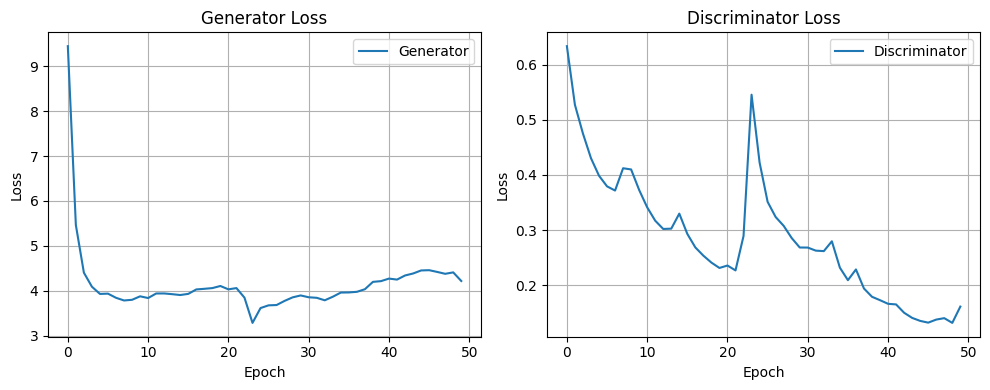


TRAINING COMPLETE!

Usage:
1. Generate video:
   video = generate_video_from_text(generator, 'image.jpg', 'smiling', 'output.mp4')

2. Visualize results:
   visualize_results(dataloader, generator, num_samples=3)


In [ ]:

import os
import cv2
import numpy as np
import torch
from PIL import Image


def tensor_video_to_uint8_frames(video_tensor: torch.Tensor) -> np.ndarray:
    """Convert model video output to uint8 RGB frames [T, H, W, 3]."""
    # Accept [B,T,C,H,W], [T,C,H,W], or [C,H,W]
    if video_tensor.dim() == 5:
        video_tensor = video_tensor[0]
    elif video_tensor.dim() == 3:
        video_tensor = video_tensor.unsqueeze(0)

    # Now expect [T, C, H, W]
    if video_tensor.dim() != 4:
        raise ValueError(f"Unexpected video tensor shape: {tuple(video_tensor.shape)}")

    frames = video_tensor.detach().float().cpu()

    # Handle outputs in [-1, 1] and [0, 1]
    if frames.min() < 0:
        frames = (frames + 1.0) / 2.0

    frames = frames.clamp(0.0, 1.0)
    frames = (frames * 255.0).round().byte()               # uint8 in [0,255]
    frames = frames.permute(0, 2, 3, 1).contiguous().numpy()  # [T,H,W,3], RGB
    return frames


def write_video_cv2(frames_rgb: np.ndarray, save_path: str, fps: float = 10.0):
    """Write RGB frames [T,H,W,3] to MP4 using cv2.VideoWriter."""
    if frames_rgb.ndim != 4 or frames_rgb.shape[-1] != 3:
        raise ValueError(f"Expected frames shape [T,H,W,3], got {frames_rgb.shape}")

    t, h, w, _ = frames_rgb.shape
    if t == 0:
        raise ValueError("No frames to write.")

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)

    # Try preferred codecs in order.
    tried = []
    writer = None
    for codec in ("mp4v", "X264"):
        fourcc = cv2.VideoWriter_fourcc(*codec)
        candidate = cv2.VideoWriter(save_path, fourcc, float(fps), (int(w), int(h)))
        tried.append(codec)
        if candidate.isOpened():
            writer = candidate
            print(f"Using codec: {codec}")
            break
        candidate.release()

    if writer is None:
        raise RuntimeError(f"Could not open VideoWriter for {save_path}. Tried codecs: {tried}")

    for i in range(t):
        frame = frames_rgb[i]

        # Ensure exact frame shape expected by writer
        if frame.shape[0] != h or frame.shape[1] != w:
            frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_AREA)

        # OpenCV expects BGR uint8
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        writer.write(frame_bgr)

    writer.release()
    print(f"Saved {t} frames at {fps} FPS -> {save_path} ({w}x{h})")


def generate_video_from_text(generator, source_image, text_prompt, save_path=None, fps=10):
    """Generate video from source image and text prompt."""
    generator.eval()

    with torch.no_grad():
        # Prepare source image
        if isinstance(source_image, str):
            source_image = Image.open(source_image).convert('RGB')
            source_image = transform(source_image).unsqueeze(0).to(device)

        # Encode directional text
        text_end = f"a photo of a person with {text_prompt}"
        text_begin = "a photo of a person"
        text_emb = generator.encode_text([text_end]) - generator.encode_text([text_begin])

        # Generate video tensor
        video_tensor = generator.generate(source_image, text_emb)

        # Convert to uint8 RGB frames [T,H,W,3]
        video_frames = tensor_video_to_uint8_frames(video_tensor)

        # Save video
        if save_path:
            write_video_cv2(video_frames, save_path=save_path, fps=fps)

        return video_frames


In [17]:
print(model)

FaceCLIPGenerator(
  (clip_model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
      (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): Sequential(
          (0): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=768, out_features=3072, bias=True)
              (gelu): QuickGELU()
              (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            )
            (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          )
          (1): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicall

In [21]:
print(checkpoint.keys())

dict_keys(['epoch', 'generator', 'discriminator', 'g_optimizer', 'd_optimizer', 'g_loss_history', 'd_loss_history'])


In [23]:

import torch
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
import os

# ==========================================================
# 1️⃣ LOAD CHECKPOINT INTO GENERATOR
# ==========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

generator = FaceCLIPGenerator(num_frames=8).to(device)

checkpoint_path = "/content/drive/MyDrive/FaceClip/faceclip_landmark_checkpoint_epoch_50.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

generator.load_state_dict(checkpoint["generator"])
generator.eval()

print("✅ Generator loaded successfully!")

# ==========================================================
# 2️⃣ IMAGE TRANSFORM (same as training)
# ==========================================================
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


def _tensor_video_to_uint8_frames(video_tensor):
    if video_tensor.dim() == 5:
        video_tensor = video_tensor[0]
    elif video_tensor.dim() == 3:
        video_tensor = video_tensor.unsqueeze(0)

    if video_tensor.dim() != 4:
        raise ValueError(f"Unexpected video tensor shape: {tuple(video_tensor.shape)}")

    frames = video_tensor.detach().float().cpu()
    if frames.min() < 0:
        frames = (frames + 1.0) / 2.0
    frames = frames.clamp(0.0, 1.0)
    frames = (frames * 255.0).round().byte()
    frames = frames.permute(0, 2, 3, 1).contiguous().numpy()
    return frames


def _write_video_cv2(frames_rgb, save_path, fps=10):
    if frames_rgb.ndim != 4 or frames_rgb.shape[-1] != 3:
        raise ValueError(f"Expected [T,H,W,3], got {frames_rgb.shape}")

    t, h, w, _ = frames_rgb.shape
    if t == 0:
        raise ValueError("No frames to write")

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)

    writer = None
    for codec in ("mp4v", "X264"):
        fourcc = cv2.VideoWriter_fourcc(*codec)
        candidate = cv2.VideoWriter(save_path, fourcc, float(fps), (int(w), int(h)))
        if candidate.isOpened():
            writer = candidate
            print(f"Using codec: {codec}")
            break
        candidate.release()

    if writer is None:
        raise RuntimeError("Could not open VideoWriter with codecs: mp4v, X264")

    for i in range(t):
        frame = frames_rgb[i]
        if frame.shape[:2] != (h, w):
            frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_AREA)
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    writer.release()

# ==========================================================
# 3️⃣ FINAL GENERATE FUNCTION (MATCHES TRAINING EXACTLY)
# ==========================================================
@torch.no_grad()
def generate_video_from_text(generator, source_image, text_prompt, save_path=None, fps=10):
    generator.eval()

    # Prepare source image
    if isinstance(source_image, str):
        source_image = Image.open(source_image).convert('RGB')
        source_image = transform(source_image).unsqueeze(0).to(device)

    # ----- TEXT ENCODING (CORRECT WAY) -----
    text_end = f"a photo of a person with {text_prompt}"
    text_begin = "a photo of a person"

    text_emb = generator.encode_text([text_end]) - generator.encode_text([text_begin])
    # ---------------------------------------

    # Generate video
    video_tensor = generator.generate(source_image, text_emb)
    video = _tensor_video_to_uint8_frames(video_tensor)

    # Save video
    if save_path:
        _write_video_cv2(video, save_path, fps=fps)
        print(f"🎬 Video saved to {save_path}")

    return video

# ==========================================================
# 4️⃣ RUN GENERATION
# ==========================================================
source_path = "/content/drive/MyDrive/FaceClip/Nosmile.jpg"
output_path = "/content/drive/MyDrive/FaceClip/final_output1.mp4"

prompt = input("Enter emotion (example: happy smiling face): ")

generate_video_from_text(generator, source_path, prompt, output_path)


Using device: cuda
✅ Generator loaded successfully!
Enter emotion (example: happy smiling face): happy smiling face
🎬 Video saved to /content/drive/MyDrive/FaceClip/final_output1.mp4


array([[[[  0,   1,   0],
         [  0,   8,  12],
         [  0,  30,   0],
         ...,
         [146, 254, 254],
         [ 12, 254, 252],
         [175, 254, 253]],

        [[  0,   0,   0],
         [  0,  11,   0],
         [  0,   0,   0],
         ...,
         [  4, 254, 195],
         [ 18, 254, 226],
         [116, 254, 201]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0, 253, 252],
         [  6, 254, 254],
         [132, 254, 254]],

        ...,

        [[  0,   0,   0],
         [  0,  25,   0],
         [  0,   0,   0],
         ...,
         [  3, 204,  98],
         [  2,  26,  14],
         [127, 234, 205]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  4,  15, 209],
         [  1,  77,  35],
         [ 13,  95, 200]],

        [[  0,   0,   0],
         [  0, 115,   0],
         [  0,   0,   0],
         ...,
         [ 62, 181, 216],
        

In [26]:
import torch
import torch.nn as nn
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"


def generate_emotion_landmarks(base_landmarks, emotion, num_frames=8):
    """
    base_landmarks: [B, 136]
    emotion: string
    returns: [B, T, 136]
    """

    B = base_landmarks.shape[0]
    landmark_dim = base_landmarks.shape[1]

    sequence = []

    for t in range(num_frames):
        alpha = (t + 1) / num_frames
        landmarks = base_landmarks.clone()
        landmarks = landmarks.view(B, 68, 2)

        # ---------------- HAPPY ----------------
        if emotion == "happy":
            mouth = list(range(48, 68))
            for i in mouth:
                landmarks[:, i, 0] += alpha * (i - 57) * 0.6
                landmarks[:, i, 1] -= alpha * 4.0

        # ---------------- SAD ----------------
        elif emotion == "sad":
            mouth = list(range(48, 68))
            for i in mouth:
                landmarks[:, i, 1] += alpha * 3.0

        # ---------------- ANGRY ----------------
        elif emotion == "angry":
            eyebrows = list(range(17, 27))
            for i in eyebrows:
                landmarks[:, i, 1] -= alpha * 3.5

        # ---------------- SURPRISE ----------------
        elif emotion == "surprise":
            mouth = list(range(48, 68))
            eyebrows = list(range(17, 27))

            for i in mouth:
                landmarks[:, i, 1] += alpha * 6.0

            for i in eyebrows:
                landmarks[:, i, 1] -= alpha * 4.0

        landmarks = landmarks.view(B, landmark_dim)
        sequence.append(landmarks)

    return torch.stack(sequence, dim=1)


In [27]:
class RuleBasedLandmarkGenerator(nn.Module):
    def __init__(self, num_frames=8):
        super().__init__()
        self.num_frames = num_frames

    def forward(self, base_landmarks, emotion):
        return generate_emotion_landmarks(
            base_landmarks,
            emotion,
            self.num_frames
        )


In [28]:
generator = FaceCLIPGenerator(num_frames=8).to(device)

checkpoint = torch.load(
    "/content/drive/MyDrive/FaceClip/faceclip_landmark_checkpoint_epoch_50.pt",
    map_location=device,
    weights_only=False
)

generator.load_state_dict(checkpoint["generator"])
generator.eval()

print("Renderer loaded successfully!")


Renderer loaded successfully!


In [29]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [30]:

@torch.no_grad()
def generate_rule_video(source_path, emotion, save_path, fps=10):
    source = Image.open(source_path).convert("RGB")
    source = transform(source).unsqueeze(0).to(device)

    bsz = source.shape[0]
    base_landmarks = torch.zeros(bsz, 136, device=device)

    rule_model = RuleBasedLandmarkGenerator(num_frames=8).to(device)
    landmark_sequence = rule_model(base_landmarks, emotion)

    # Renderer output is expected to be [B,T,C,H,W]
    video_tensor = generator.renderer(source, landmark_sequence)

    # Reuse the robust conversion + writer helpers
    video_frames = tensor_video_to_uint8_frames(video_tensor)
    write_video_cv2(video_frames, save_path=save_path, fps=fps)

    return video_frames


In [31]:
generate_rule_video(
    "/content/drive/MyDrive/FaceClip/Nosmile.jpg",
    emotion="happy",
    save_path="/content/drive/MyDrive/FaceClip/rule_based_smile.mp4"
)


Video saved to /content/drive/MyDrive/FaceClip/rule_based_smile.mp4
